In [ ]:
pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
wine_quality = fetch_ucirepo(id=186)

# data (as pandas dataframes)
X = wine_quality.data.features
y = wine_quality.data.targets

# metadata
print(wine_quality.metadata)

# variable information
print(wine_quality.variables)


{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
# Install the library if not already present
# !pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import StandardScaler

# Fetch dataset
wine_quality = fetch_ucirepo(id=186)
X = wine_quality.data.features
y = wine_quality.data.targets

# Convert to Binary Classification (Student-friendly logic)
# Logistic Regression needs categories. We'll label wine with quality >= 6 as '1' (Good) and < 6 as '0' (Bad).
y_binary = (y >= 6).astype(int)

print(f"Dataset loaded. Features: {X.shape[1]}, Target classes: {np.unique(y_binary)}")

Dataset loaded. Features: 11, Target classes: [0 1]


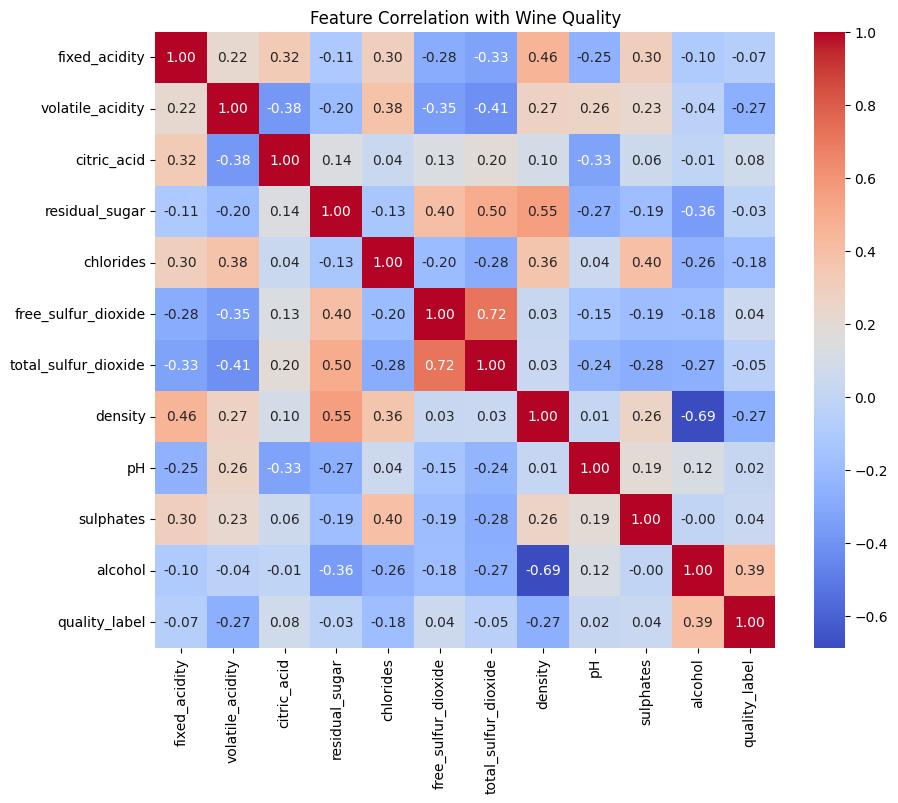

In [ ]:
# Combine for a quick correlation heatmap
temp_df = X.copy()
temp_df['quality_label'] = y_binary

plt.figure(figsize=(10, 8))
sns.heatmap(temp_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation with Wine Quality")
plt.show()

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.2, random_state=42)

# Scaling is mandatory for Logistic Regression convergence
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

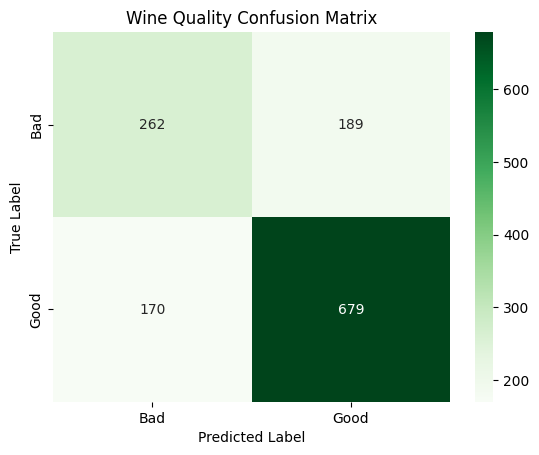

--- Classification Metrics ---
              precision    recall  f1-score   support

           0       0.61      0.58      0.59       451
           1       0.78      0.80      0.79       849

    accuracy                           0.72      1300
   macro avg       0.69      0.69      0.69      1300
weighted avg       0.72      0.72      0.72      1300



In [ ]:
# Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train.values.ravel())

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Visualization: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Bad', 'Good'], yticklabels=['Bad', 'Good'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Wine Quality Confusion Matrix')
plt.show()

# Classification Report
print("--- Classification Metrics ---")
print(classification_report(y_test, y_pred))

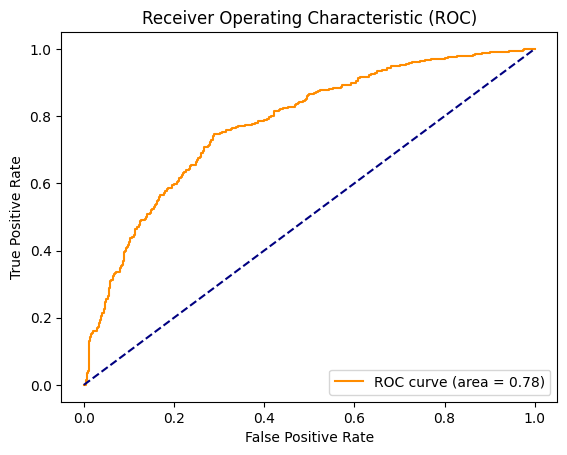

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, color='darkorange', label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--')
plt.title('Receiver Operating Characteristic (ROC)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

In [ ]:
def predict_wine_quality(features_list):
    # features_list: [fixed acidity, volatile acidity, ..., alcohol]
    scaled_input = scaler.transform([features_list])
    prediction = model.predict(scaled_input)
    prob = model.predict_proba(scaled_input)[0][1]

    label = "Good 🍷" if prediction[0] == 1 else "Bad ❌"
    print(f"Prediction: {label} (Confidence: {prob*100:.2f}%)")

# Example: Testing with average values for a wine
# Replace these with real-time user inputs
test_sample = [7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4]
predict_wine_quality(test_sample)

Prediction: Bad ❌ (Confidence: 16.35%)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


/tmp/ipykernel_7095/1828458338.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')


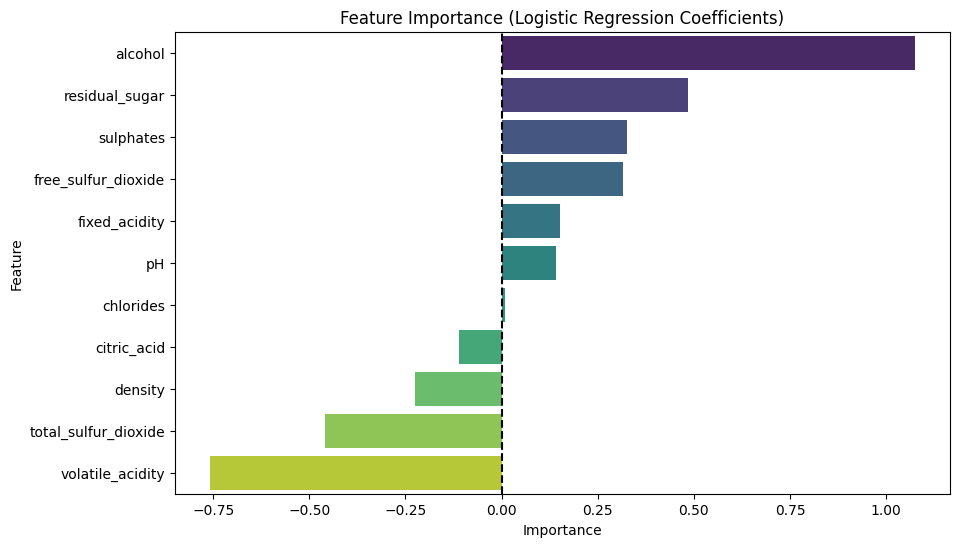

Interpretation for Students:
- Positive values (to the right): Increasing these features increases the chance of 'Good' wine.
- Negative values (to the left): Increasing these features increases the chance of 'Bad' wine.


In [ ]:
# Extract coefficients
importance = model.coef_[0]
feature_names = X.columns

# Create a DataFrame for visualization
feature_importance = pd.DataFrame({'Feature': feature_names, 'Importance': importance})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='viridis')
plt.title('Feature Importance (Logistic Regression Coefficients)')
plt.axvline(x=0, color='black', linestyle='--') # Add a vertical line at 0
plt.show()

print("Interpretation for Students:")
print("- Positive values (to the right): Increasing these features increases the chance of 'Good' wine.")
print("- Negative values (to the left): Increasing these features increases the chance of 'Bad' wine.")

In [ ]:
import joblib

# Save the model and the scaler
joblib.dump(model, 'wine_quality_model.pkl')
joblib.dump(scaler, 'wine_scaler.pkl')

print("Model and Scaler saved successfully! Ready for deployment.")

Model and Scaler saved successfully! Ready for deployment.
